In [1]:
!pip install yfinance

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [ ]:

ticker = '^NSEI'

data = yf.download(ticker, start='2022-01-01', end='2026-03-30')

# Fix multi-index issue
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)

print("Raw Data:", data.shape)
print(data.tail())


In [3]:
price = data['Adj Close'] if 'Adj Close' in data.columns else data['Close']

data['Return'] = price.pct_change()

Converts price → returns (stationary series).

Financial models work on returns, not prices.

This step makes data usable for volatility modeling

In [ ]:
# Annualized rolling volatility (sqrt(252) converts daily std to annual %)
data['Realized Vol'] = data['Return'].rolling(5).std() * np.sqrt(252)
data['Prev Vol'] = data['Realized Vol'].shift(1)

vol_data = data[['Realized Vol', 'Prev Vol']].dropna()

print("Vol Data:", vol_data.shape)

Measures market uncertainty (risk).

Rolling window = local volatility estimate.

Lagged vol allows testing time dependence

Making it my core signal construction step

In [ ]:
slope, intercept, r_value, p_value, std_err = linregress(
    vol_data['Prev Vol'], vol_data['Realized Vol']
)

print(f"Slope:   {slope:.5f}  (persistence strength; 1.0 = random walk in vol)")
print(f"R²:      {r_value**2:.5f}  (fraction of variance explained)")
print(f"p-value: {p_value:.2e}  ({'statistically significant' if p_value < 0.05 else 'NOT significant'})")
print(f"Std Err: {std_err:.6f}")

Tests volatility clustering hypothesis
Slope ≈ persistence strength
R² ≈ explanatory power making it a simplified version of ARCH/GARCH logic.

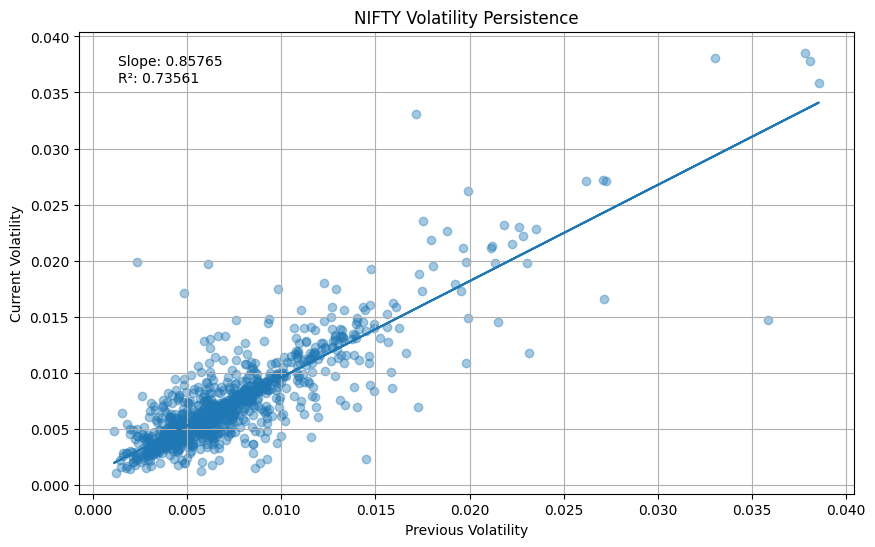

In [7]:
plt.figure(figsize=(10,6))

plt.scatter(vol_data['Prev Vol'], vol_data['Realized Vol'], alpha=0.4)

trend = slope * vol_data['Prev Vol'] + intercept
plt.plot(vol_data['Prev Vol'], trend)

plt.title("NIFTY Volatility Persistence")
plt.xlabel("Previous Volatility")
plt.ylabel("Current Volatility")

plt.text(0.05, 0.95,
         f"Slope: {slope:.5f}\nR²: {r_value**2:.5f}",
         transform=plt.gca().transAxes,
         verticalalignment='top')

plt.grid(True)
plt.show()

Provides visual confirmation of statistical result
Scatter → structure of dependence
Line → strength of persistence

Visualization = sanity check + intuition

In [8]:
data['GK Var'] = 0.5 * (np.log(data['High'] / data['Low']) ** 2) - \
                 (2*np.log(2) - 1) * (np.log(data['Close'] / data['Open']) ** 2)

In [9]:
data['CC Var'] = data['Return'] ** 2

In [10]:
data['Rolling GK'] = data['GK Var'].rolling(10).sum()
data['Rolling CC'] = data['CC Var'].rolling(10).sum()

data['Variance Ratio'] = data['Rolling GK'] / data['Rolling CC']

vr_data = data[['Variance Ratio']].dropna()

Significance:
Compares intraday vs daily volatility.

Detects hidden market activity and captures microstructure inefficiencies

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(vr_data.index, vr_data['Variance Ratio'], label='Variance Ratio')

# Reference line: ratio = 1 means GK vol == Close-Close vol (no hidden activity)
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, label='Baseline (GK = CC)')

ax.set_title("Variance Ratio (GK / Close-Close)")
ax.set_ylabel("Variance Ratio")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

print("→ Ratio > 1: Intraday range volatility exceeds close-close vol → hidden intraday activity or trend.")
print("→ Ratio < 1: Close-close vol dominates → gap risk or overnight jumps more significant.")
print("→ Ratio = 1 (red dashed): Both estimators agree, market is 'well-behaved'.\n")

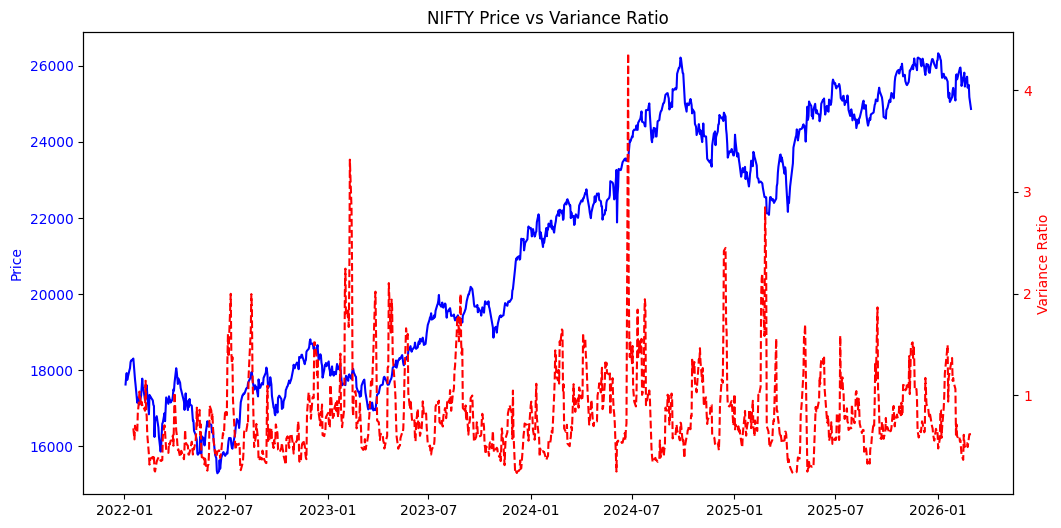

In [14]:
fig, ax1 = plt.subplots(figsize=(12,6))

# Price (left axis)
ax1.plot(data.index, price, label='Price', color='blue')
ax1.set_ylabel("Price", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Variance Ratio (right axis)
ax2 = ax1.twinx()
ax2.plot(data.index, data['Variance Ratio'], linestyle='--', color='red', label='Variance Ratio')
ax2.set_ylabel("Variance Ratio", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title
plt.title("NIFTY Price vs Variance Ratio")

plt.show()

Links market movement ↔ volatility structure.
It Shows how volatility behaves during trends/crashes
It is Useful for regime detection + trading signals